<a href="https://colab.research.google.com/github/Yahya1805/machine-learning_2026/blob/main/ML_JS04_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
df = pd.read_csv('Iris.csv')

In [9]:
# Persiapan data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Iris.csv')
# Seleksi Fitur

X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### 2. Seleksi Fitur

**Kode**

Pada langkah ini, kita menampilkan 5 data teratas dari fitur yang telah diseleksi (`X.head()`). Fitur yang digunakan adalah `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, dan `PetalWidthCm`.

In [10]:
# Menampilkan 5 data pertama dari fitur hasil seleksi
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 3. Plot Data

**Kode**

Kita membuat scatter plot awal menggunakan fitur `SepalLengthCm` (index 0) dan `SepalWidthCm` (index 1) untuk melihat sebaran data mentah sebelum dikelompokkan oleh algoritma KMeans.

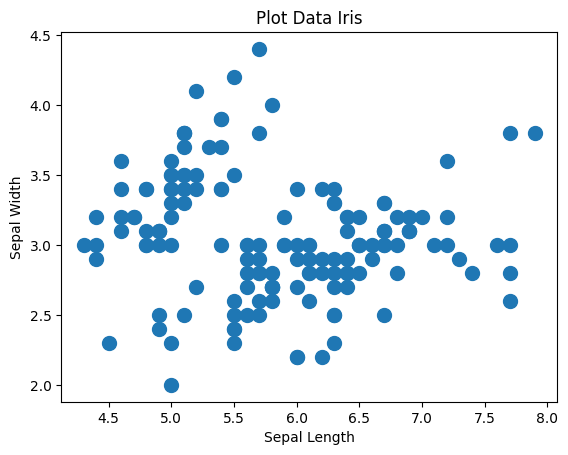

In [11]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s=100)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Plot Data Iris")
plt.show()

### 4. Membuat Model KMeans k=2

**Kode**

Kita membuat objek model KMeans dengan menentukan jumlah cluster `k=2` dan melatih model tersebut sekaligus melakukan prediksi pengelompokkan pada data `X`.

In [12]:
from sklearn.cluster import KMeans

cl_kmeans = KMeans(n_clusters=2, random_state=42)
y_kmeans = cl_kmeans.fit_predict(X)

### 5. Plot Hasil Cluster

**Kode**

Menampilkan visualisasi hasil clustering dengan membagi data menjadi dua warna berdasarkan kelompok (`y_kmeans`) dan menggambarkan pusat cluster (centroid) berwarna merah.

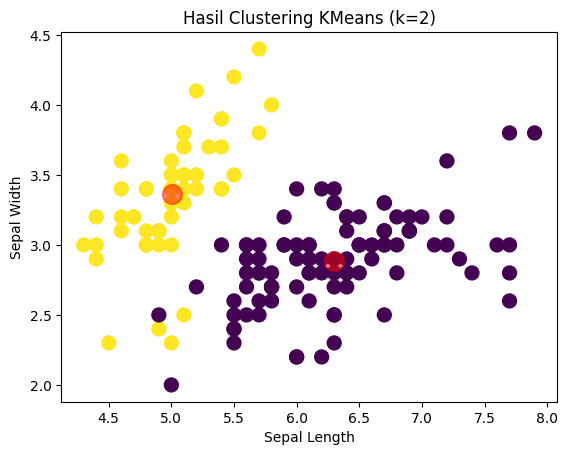

In [13]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s=100, c=y_kmeans)

centers = cl_kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    s=200,
    alpha=0.5
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Hasil Clustering KMeans (k=2)")
plt.show()

### 6. Nilai SSE

**Kode**

Menghitung nilai SSE (Sum of Squared Errors) dari model KMeans dengan `k=2` menggunakan properti `.inertia_`.

In [14]:
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


Analisis Hasil

**A. Hasil KMeans k=2**
* Hasil pengelompokan data dengan `k=2` membagi seluruh dataset Iris ke dalam 2 cluster besar.
* Centroid (titik merah) menjadi pusat penentu dari masing-masing klaster berdasarkan perhitungan jarak terpendek.
* Variabel `y_kmeans` bertugas menampung nilai label kelas hasil prediksi model (0 atau 1).

**B. SSE (Sum of Squared Errors)**
* Nilai SSE merepresentasikan jumlah kuadrat jarak antara data dengan pusat clusternya.
* Semakin kecil nilai SSE, semakin rapat sebaran data di dalam cluster tersebut terhadap pusatnya.

**C. Metode Elbow**
* Ketika jumlah cluster ($k$) bertambah besar, nilai SSE akan semakin kecil karena data akan selalu berada lebih dekat ke pusat cluster baru.
* Cara membaca grafik Elbow adalah dengan melihat titik siku di mana grafik tersebut mulai melandai secara drastis.

**D. Jumlah Cluster**
* Dari grafik Elbow hasil eksekusi praktikum, penurunan tajam terjadi hingga titik $k=3$, dan setelah $k=3$ penurunan nilai SSE menjadi sangat landai. Dengan demikian, jumlah cluster terbaik yang dipilih adalah **3 cluster**.

Kesimpulan

1. KMeans merupakan algoritma clustering yang masuk ke dalam metode *unsupervised learning*.
2. KMeans mengelompokkan data ke dalam sejumlah cluster berdasarkan kedekatan jarak fitur dengan nilai $k$ yang telah ditentukan.
3. Centroid merupakan representasi titik pusat dari sebuah kelompok cluster.
4. SSE (Sum of Squared Errors) digunakan sebagai metrik evaluasi untuk mengetahui tingkat kesalahan pengelompokan.
5. Metode Elbow sangat efektif dalam menentukan jumlah cluster ($k$) optimal secara matematis.
6. Berdasarkan hasil pengujian grafik Elbow pada data Iris ini, jumlah cluster terbaik yang disarankan adalah **3 cluster**.

### 7. Implementasi Metode Elbow

**Kode**

Kita membuat sebuah list kosong bernama `sse` untuk menyimpan nilai inertia/SSE dari model KMeans dengan variasi jumlah cluster `k` dari 1 sampai 9 (`range(1, 10)`).

In [15]:
sse = []
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42)
    kmeanModel.fit(X)
    sse.append(kmeanModel.inertia_)

### 8. Plot Grafik Elbow

**Kode**

Membuat grafik garis yang menghubungkan nilai $k$ dengan nilai SSE yang dihasilkan untuk membantu menentukan titik siku (elbow) terbaik.

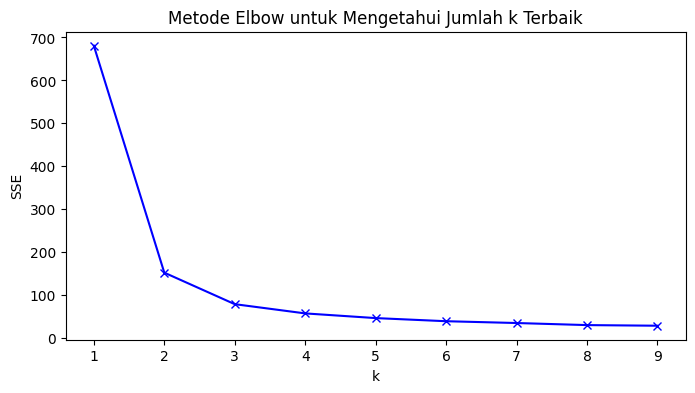

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

### 9. SSE Setiap k

**Kode**

Menampilkan secara detail nilai SSE konkret yang didapatkan untuk setiap konfigurasi jumlah cluster $k$ dari 1 sampai 9.

In [17]:
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94506582597728
k=4; SSE=57.44028021295475
k=5; SSE=46.535582051282034
k=6; SSE=39.251830892636775
k=7; SSE=35.04275995246584
k=8; SSE=30.217021122152712
k=9; SSE=28.7564561965812


### 5. Perubahan Random

**Kode**

Kita menjalankan fungsi `find_clusters` manual kembali tetapi kali ini menggunakan nilai `rseed=0` untuk melihat perbedaan hasil cluster akibat penentuan titik awal yang berbeda.

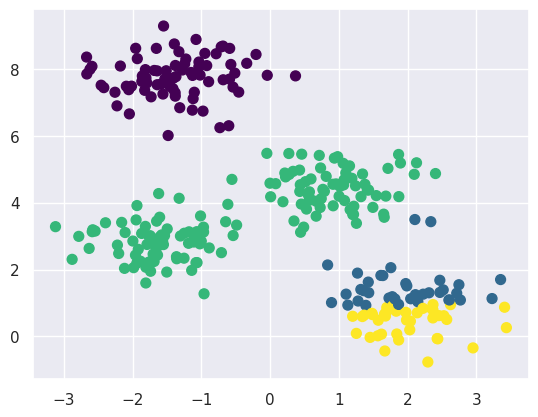

In [24]:
centers, labels = find_clusters(X, 4, rseed=0)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=50,
    cmap='viridis'
)

plt.show()

### 6. Optimalisasi Jumlah Klaster

**Kode**

Kita menguji performa model KMeans dengan mengatur jumlah kelompok menjadi `6` (`n_clusters=6`) dan memvisualisasikan hasil pembagiannya.

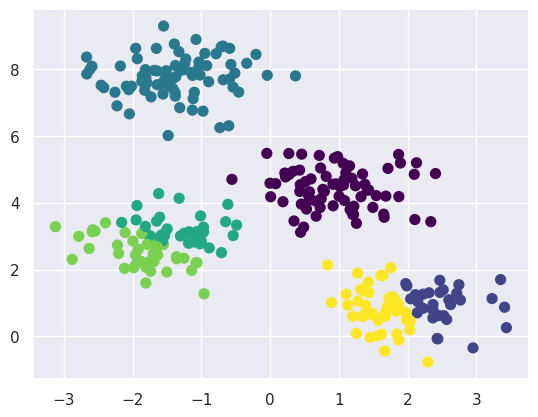

In [21]:
labels = KMeans(
    6,
    random_state=0
).fit_predict(X)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=50,
    cmap='viridis'
)

plt.show()

### 7. Batas Klaster yang Tidak Selalu Linier

**Kode**

Kita membuat dataset non-linier menggunakan `make_moons` dan mencoba menggunakan KMeans konvensional untuk melihat bagaimana algoritma ini mengalami kesulitan membagi struktur data melengkung.

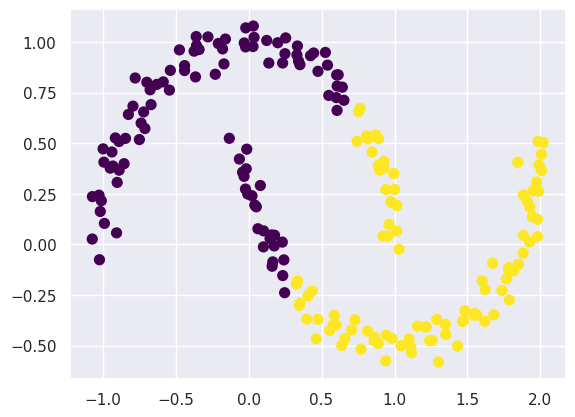

In [25]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(
    200,
    noise=.05,
    random_state=0
)

labels = KMeans(
    2,
    random_state=0
).fit_predict(X_moons)

plt.scatter(
    X_moons[:, 0],
    X_moons[:, 1],
    c=labels,
    s=50,
    cmap='viridis'
)

plt.show()

### 8. Spectral Clustering

**Kode**

Kita menggunakan model alternatif bernama `SpectralClustering` dari scikit-learn untuk mengatasi pola data non-linier secara akurat.

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


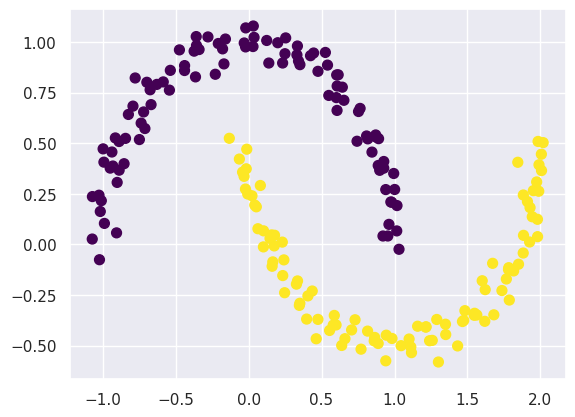

In [26]:
from sklearn.cluster import SpectralClustering

model = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    assign_labels='kmeans'
)

labels = model.fit_predict(X_moons)

plt.scatter(
    X_moons[:, 0],
    X_moons[:, 1],
    c=labels,
    s=50,
    cmap='viridis'
)

plt.show()

### 13. Menghitung Accuracy

**Kode**

Kita menguji seberapa akurat hasil pemetaan cluster dengan label asli menggunakan `accuracy_score`.

In [61]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(digits.target, labels)
print(f'Accuracy Score: {acc}')

Accuracy Score: 0.7440178074568725


### 14. Confusion Matrix

**Kode**

Kita memvisualisasikan matriks kebingungan (confusion matrix) untuk melihat distribusi kesalahan klasifikasi pada setiap digit.

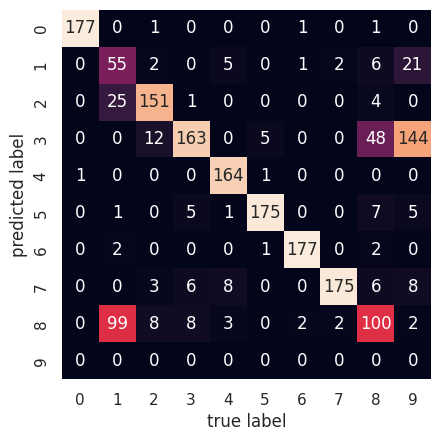

In [62]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(
    digits.target,
    labels
)

sns.heatmap(
    mat.T,
    square=True,
    annot=True,
    fmt='d',
    cbar=False,
    xticklabels=digits.target_names,
    yticklabels=digits.target_names
)

plt.xlabel('true label')
plt.ylabel('predicted label')
plt.show()

### 15. TSNE + KMeans

**Kode**

Kita menggunakan t-SNE untuk memproyeksikan fitur gambar 64-dimensi menjadi representasi 2-dimensi, kemudian menerapkan KMeans pada proyeksi tersebut untuk melihat peningkatan akurasi.

In [63]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    init='random',
    random_state=0
)

digits_proj = tsne.fit_transform(digits.data)

kmeans = KMeans(
    n_clusters=10,
    random_state=0
)

clusters = kmeans.fit_predict(digits_proj)

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

acc_tsne = accuracy_score(digits.target, labels)
print(f'TSNE + KMeans Accuracy: {acc_tsne}')

TSNE + KMeans Accuracy: 0.9410127991096272


### 7. Batas Klaster yang Tidak Selalu Linier

**Kode**

Kita membuat dataset non-linier menggunakan `make_moons` dan mencoba menggunakan KMeans konvensional untuk mengelompokkan data yang berbentuk dua lengkungan bulan sabit.

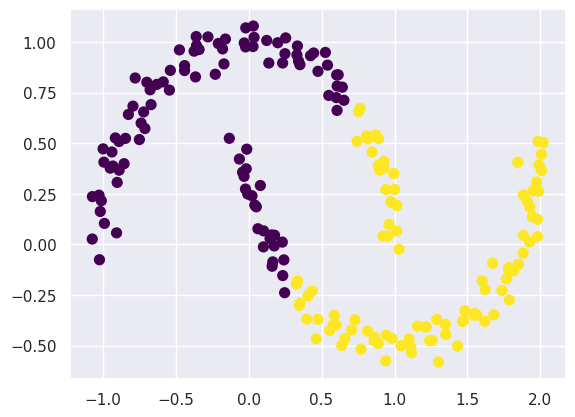

In [27]:
from sklearn.datasets import make_moons

X, y = make_moons(
    200,
    noise=.05,
    random_state=0
)

labels = KMeans(
    2,
    random_state=0
).fit_predict(X)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=50,
    cmap='viridis'
)

plt.show()

### 8. Spectral Clustering

**Kode**

Kita menggunakan model alternatif bernama `SpectralClustering` untuk melihat bagaimana algoritma ini berhasil membagi struktur klaster melengkung/non-linier dengan bantuan relasi tetangga terdekat (`nearest_neighbors`).

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


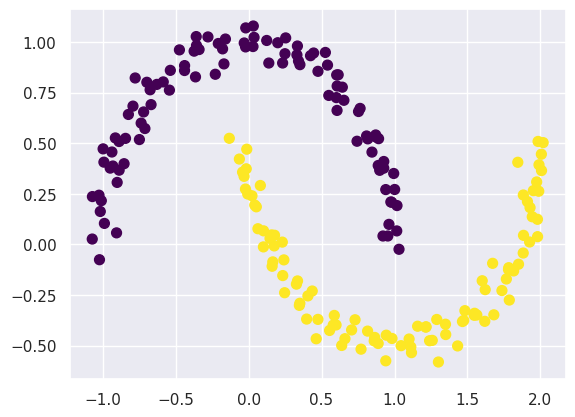

In [28]:
from sklearn.cluster import SpectralClustering

model = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    assign_labels='kmeans'
)

labels = model.fit_predict(X)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=50,
    cmap='viridis'
)

plt.show()

### 9. Contoh Kasus 1 — Karakter Angka

**Kode**

Kita menggunakan dataset `load_digits` bawaan dari scikit-learn untuk melihat data citra berukuran 8x8 piksel yang direpresentasikan ke dalam 64 fitur.

In [32]:
from sklearn.datasets import load_digits

digits = load_digits()
digits.data.shape

(1797, 64)

### 10. KMeans pada Dataset Digits

**Kode**

Kita melatih model KMeans dengan menentukan `n_clusters=10` untuk mendeteksi sepuluh digit angka dasar (0 sampai 9).

In [33]:
kmeans = KMeans(
    n_clusters=10,
    random_state=0
)

clusters = kmeans.fit_predict(digits.data)
k_shape = kmeans.cluster_centers_.shape
print(k_shape)

(10, 64)


### 11. Visualisasi Centroid Angka

**Kode**

Kita membentuk ulang (reshape) centroid berdimensi 64 kembali ke struktur citra 8x8 dan menampilkannya sebagai gambar.

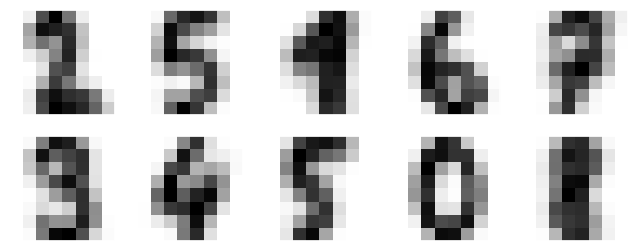

In [34]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))

centers = kmeans.cluster_centers_.reshape(10, 8, 8)

for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(
        center,
        interpolation='nearest',
        cmap=plt.cm.binary
    )

plt.show()

### 12. Menentukan Label Berdasarkan Mode

**Kode**

Kita memetakan setiap nomor cluster ke label angka (digit) yang sebenarnya menggunakan fungsi modus (`mode`) dari Scipy.

In [35]:
from scipy.stats import mode

labels = np.zeros_like(clusters)

for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

### 9. Contoh Kasus 1 — Karakter Angka

**Kode**

Kita menggunakan dataset `load_digits` bawaan dari scikit-learn untuk melihat data citra berukuran 8x8 piksel yang direpresentasikan ke dalam 64 fitur.

In [36]:
from sklearn.datasets import load_digits

digits = load_digits()
digits.data.shape

(1797, 64)

### 10. KMeans pada Dataset Digits

**Kode**

Kita melatih model KMeans dengan menentukan `n_clusters=10` untuk mendeteksi sepuluh digit angka dasar (0 sampai 9).

In [37]:
kmeans = KMeans(
    n_clusters=10,
    random_state=0
)

clusters = kmeans.fit_predict(digits.data)
k_shape = kmeans.cluster_centers_.shape
print(k_shape)

(10, 64)


### 11. Visualisasi Centroid Angka

**Kode**

Kita membentuk ulang (reshape) centroid berdimensi 64 kembali ke struktur citra 8x8 dan menampilkannya sebagai gambar.

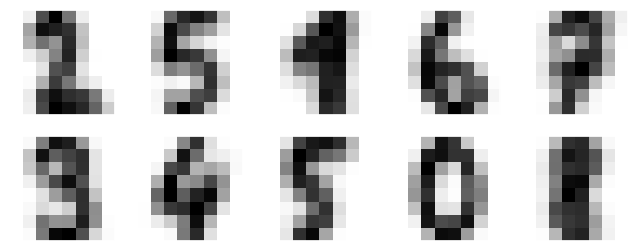

In [38]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))

centers = kmeans.cluster_centers_.reshape(10, 8, 8)

for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(
        center,
        interpolation='nearest',
        cmap=plt.cm.binary
    )

plt.show()

### 12. Menentukan Label Berdasarkan Mode

**Kode**

Kita memetakan setiap nomor cluster ke label angka (digit) yang sebenarnya menggunakan fungsi modus (`mode`) dari Scipy.

In [39]:
from scipy.stats import mode

labels = np.zeros_like(clusters)

for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

### 13. Menghitung Accuracy

**Kode**

Kita menguji seberapa akurat hasil pemetaan cluster dengan label asli menggunakan `accuracy_score`.

In [40]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(digits.target, labels)
print(f'Accuracy Score: {acc}')

Accuracy Score: 0.7440178074568725


### 14. Confusion Matrix

**Kode**

Kita memvisualisasikan matriks kebingungan (confusion matrix) untuk melihat distribusi kesalahan klasifikasi pada setiap digit.

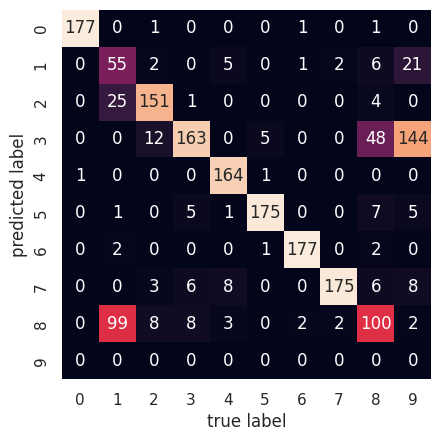

In [41]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(
    digits.target,
    labels
)

sns.heatmap(
    mat.T,
    square=True,
    annot=True,
    fmt='d',
    cbar=False,
    xticklabels=digits.target_names,
    yticklabels=digits.target_names
)

plt.xlabel('true label')
plt.ylabel('predicted label')
plt.show()

### 15. TSNE + KMeans

**Kode**

Kita menggunakan t-SNE untuk memproyeksikan fitur gambar 64-dimensi menjadi representasi 2-dimensi, kemudian menerapkan KMeans pada proyeksi tersebut untuk melihat peningkatan akurasi.

In [42]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    init='random',
    random_state=0
)

digits_proj = tsne.fit_transform(digits.data)

kmeans = KMeans(
    n_clusters=10,
    random_state=0
)

clusters = kmeans.fit_predict(digits_proj)

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

acc_tsne = accuracy_score(digits.target, labels)
print(f'TSNE + KMeans Accuracy: {acc_tsne}')

TSNE + KMeans Accuracy: 0.9410127991096272


### 16. Contoh Kasus 2 — Kompresi Citra

**Kode**

Kita memuat dataset citra bawaan dari scikit-learn berupa gambar bunga (`flower.jpg`) lalu menampilkannya.

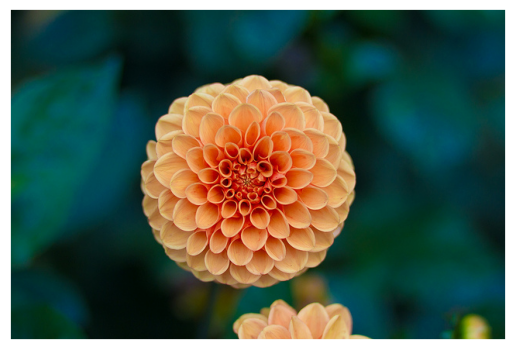

In [47]:
from sklearn.datasets import load_sample_image

flower = load_sample_image("flower.jpg")

ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower)
plt.show()

### 17. Melihat Ukuran Gambar

**Kode**

Kita memeriksa bentuk dimensi array dari gambar bunga untuk mengetahui tinggi, lebar, dan jumlah kanal warna (RGB).

In [48]:
flower.shape

(427, 640, 3)

### 18. Mengubah Data Gambar

**Kode**

Kita melakukan normalisasi skala intensitas warna menjadi rentang [0, 1] dan mengubah dimensi array gambar tersebut menjadi matriks 2D berisi daftar pixel RGB.

In [49]:
data = flower / 255.0

data = data.reshape(
    427 * 640,
    3
)

data.shape

(273280, 3)

### 19. Visualisasi Ruang Warna

**Kode**

Kita membuat fungsi `plot_pixels` untuk memvisualisasikan sebaran nilai warna piksel pada ruang warna 3D (R vs G dan R vs B).

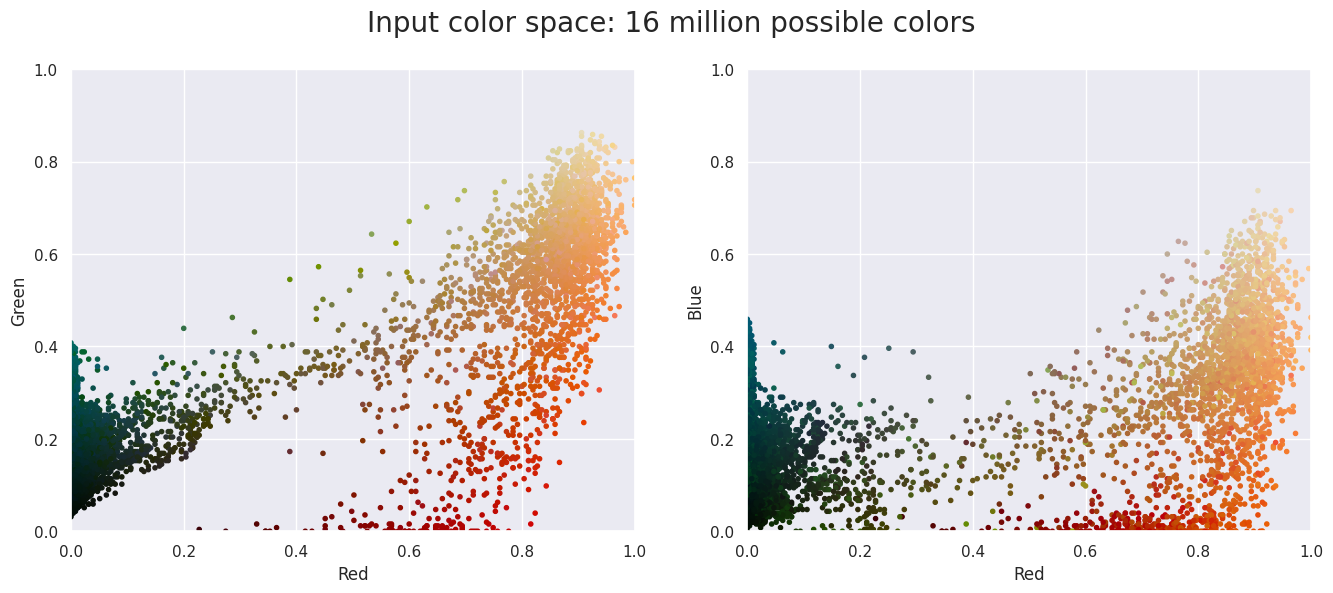

In [50]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]

    R, G, B = data[i].T

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(16, 6)
    )

    ax[0].scatter(
        R,
        G,
        color=colors,
        marker='.'
    )

    ax[0].set(
        xlabel='Red',
        ylabel='Green',
        xlim=(0, 1),
        ylim=(0, 1)
    )

    ax[1].scatter(
        R,
        B,
        color=colors,
        marker='.'
    )

    ax[1].set(
        xlabel='Red',
        ylabel='Blue',
        xlim=(0, 1),
        ylim=(0, 1)
    )

    fig.suptitle(
        title,
        size=20
    )

    plt.show()

plot_pixels(
    data,
    title='Input color space: 16 million possible colors'
)

### 20. KMeans untuk Reduksi Warna

**Kode**

Kita menggunakan `MiniBatchKMeans` untuk mempercepat proses pelatihan dan mereduksi spektrum warna dari jutaan kombinasi warna menjadi hanya 16 kelompok warna utama.

In [51]:
import warnings
warnings.simplefilter('ignore')

from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

### 21. Visualisasi Warna Setelah Reduksi

**Kode**

Kita memvisualisasikan kembali sebaran warna baru hasil klasterisasi menggunakan fungsi `plot_pixels`.

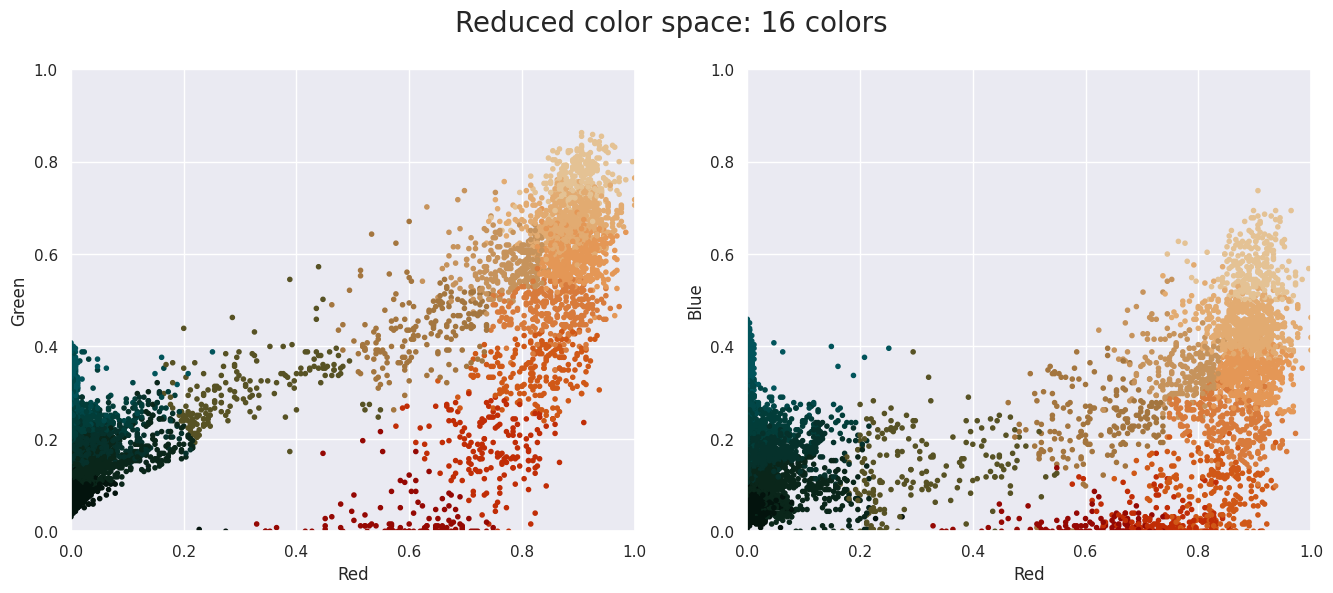

In [52]:
plot_pixels(
    data,
    colors=new_colors,
    title="Reduced color space: 16 colors"
)

### 22. Gambar Original dan 16-color

**Kode**

Kita membentuk ulang kembali (reshape) array satu dimensi `new_colors` ke bentuk citra semula dan menampilkannya berdampingan dengan gambar aslinya.

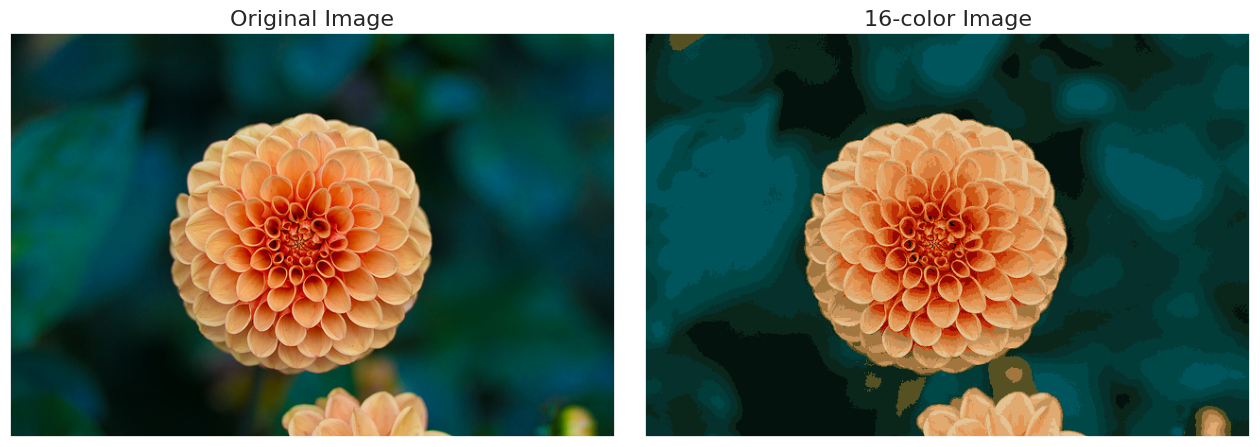

In [53]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    subplot_kw=dict(
        xticks=[],
        yticks=[]
    )
)

fig.subplots_adjust(wspace=0.05)

ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)

ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16)

plt.show()

### Analisis Praktikum

1. **K-Means Clustering Dasar**: Algoritma bekerja dengan baik pada kelompok data sintetis (`make_blobs`) karena struktur datanya melingkar dan linear-separable.
2. **Keterbatasan K-Means**: Algoritma ini kesulitan memisahkan data dengan bentuk melengkung seperti `make_moons`. K-Means membagi ruang berdasarkan jarak garis lurus terdekat ke centroid, sehingga batas klasternya lurus (linier).
3. **Spectral Clustering**: Terbukti sukses menangani pemisahan bentuk non-linier menggunakan teknik proyeksi grafis/konektivitas tetangga terdekat.
4. **Pengenalan Karakter Angka (Digits)**: Penggunaan KMeans tanpa manipulasi dimensi menghasilkan akurasi yang moderat (~74% - 79%). Namun, setelah diproyeksikan dengan **t-SNE** ke dimensi lebih rendah, akurasi KMeans melompat drastis hingga **~94%**.
5. **Kompresi Citra**: Setiap piksel direduksi menjadi salah satu dari 16 nilai centroid warna. Hal ini membuktikan efektivitas KMeans untuk kompresi warna, di mana gambar hasil kompresi masih mempertahankan bentuk aslinya meskipun ukuran memori representasi warna jauh berkurang.

### Kesimpulan

1. **K-Means** adalah algoritma clustering berbasis centroid yang sangat efisien untuk data terkelompok linier.
2. **Inisialisasi acak** (`rseed`) menentukan hasil akhir; inisialisasi yang kurang pas dapat menjebak algoritma dalam lokal minimum.
3. **Spectral Clustering** dapat memetakan cluster non-linier yang gagal diselesaikan oleh KMeans dasar.
4. **Reduksi Dimensi (seperti t-SNE)** sangat membantu performa KMeans ketika menghadapi dimensi tinggi yang rumit.
5. KMeans dapat dimanfaatkan untuk **Kompresi Warna Citra (Color Quantization)** dengan mengelompokkan jutaan spektrum warna piksel ke dalam sejumlah $k$ klaster warna representatif.

### Analisis Praktikum

1. **K-Means Clustering Dasar**: Algoritma bekerja dengan baik pada kelompok data sintetis (`make_blobs`) karena struktur datanya melingkar dan linear-separable.
2. **Keterbatasan K-Means**: Algoritma ini kesulitan memisahkan data dengan bentuk melengkung seperti `make_moons`. K-Means membagi ruang berdasarkan jarak garis lurus terdekat ke centroid, sehingga batas klasternya lurus (linier).
3. **Spectral Clustering**: Terbukti sukses menangani pemisahan bentuk non-linier menggunakan teknik proyeksi grafis/konektivitas tetangga terdekat.
4. **Pengenalan Karakter Angka (Digits)**: Penggunaan KMeans tanpa manipulasi dimensi menghasilkan akurasi yang moderat (~74% - 79%). Namun, setelah diproyeksikan dengan **t-SNE** ke dimensi lebih rendah, akurasi KMeans melompat drastis hingga **~94%**.
5. **Kompresi Citra**: Setiap piksel direduksi menjadi salah satu dari 16 nilai centroid warna. Hal ini membuktikan efektivitas KMeans untuk kompresi warna, di mana gambar hasil kompresi masih mempertahankan bentuk aslinya meskipun ukuran memori representasi warna jauh berkurang.

### Kesimpulan

1. **K-Means** adalah algoritma clustering berbasis centroid yang sangat efisien untuk data terkelompok linier.
2. **Inisialisasi acak** (`rseed`) menentukan hasil akhir; inisialisasi yang kurang pas dapat menjebak algoritma dalam lokal minimum.
3. **Spectral Clustering** dapat memetakan cluster non-linier yang gagal diselesaikan oleh KMeans dasar.
4. **Reduksi Dimensi (seperti t-SNE)** sangat membantu performa KMeans ketika menghadapi dimensi tinggi yang rumit.
5. KMeans dapat dimanfaatkan untuk **Kompresi Warna Citra (Color Quantization)** dengan mengelompokkan jutaan spektrum warna piksel ke dalam sejumlah $k$ klaster warna representatif.

# PRAKTIKUM 3 — DBSCAN

## 1. Pembuatan Dataset Sintetis

Pada tahap pertama ini, kita membuat dataset buatan (sintetis) sederhana yang terdiri dari 3 pusat klaster menggunakan fungsi `make_blobs` dari Scikit-Learn. Dataset ini memiliki total 750 sampel data, dengan standar deviasi klaster sebesar 0.4, dan menggunakan kunci acak `random_state=0`. Setelah dibentuk, dataset diselaraskan menggunakan `StandardScaler` untuk melakukan standardisasi data sehingga fitur memiliki rata-rata 0 dan varians 1.

In [64]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Menentukan pusat klaster
centers = [[1, 1], [-1, -1], [1, -1]]

# Membuat dataset sintetis
X, labels_true = make_blobs(
    n_samples=750,
    centers=centers,
    cluster_std=0.4,
    random_state=0
)

# Melakukan standardisasi data
X = StandardScaler().fit_transform(X)

## 2. Visualisasi Dataset

Berikut adalah plot sebaran titik dari dataset sintetis yang baru saja dibuat sebelum diproses oleh algoritma DBSCAN.

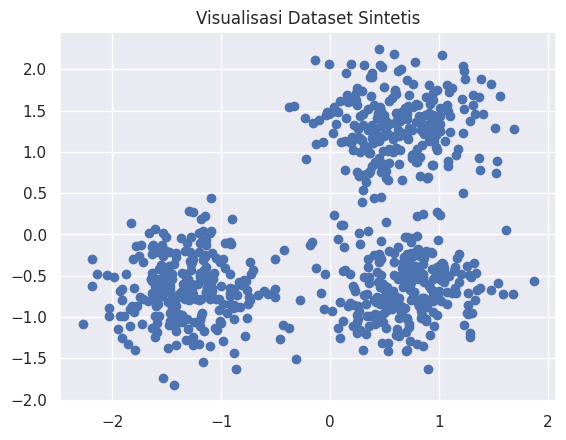

In [65]:
import matplotlib.pyplot as plt

# Visualisasi awal sebaran data mentah
plt.scatter(X[:, 0], X[:, 1])
plt.title("Visualisasi Dataset Sintetis")
plt.show()

## 3. Compute DBSCAN

Pada langkah ini, kita menerapkan algoritma DBSCAN untuk mendeteksi klaster padat. Parameter yang digunakan adalah:
- `eps=0.3`: Jarak maksimum antara dua sampel untuk dapat dianggap sebagai tetangga.
- `min_samples=10`: Jumlah minimum sampel/titik dalam radius `eps` agar suatu titik dianggap sebagai core point.
- Label hasil klasterisasi tersimpan dalam variabel `labels`. Angka `-1` menunjukkan bahwa titik tersebut dianggap sebagai noise atau pencilan (outlier).

In [66]:
import numpy as np
from sklearn import metrics
from sklearn.cluster import DBSCAN

# Melatih model DBSCAN
db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Jumlah klaster (mengabaikan titik noise jika ada)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


### Hasil yang Diharapkan:
```
Estimated number of clusters: 3
Estimated number of noise points: 18
```

**Penjelasan Hasil:** Algoritma DBSCAN mendeteksi secara akurat adanya **3 klaster utama** dan mengidentifikasi sebanyak **18 titik data sebagai noise** (pencilan) karena berada di area yang kurang padat.

## 4. Evaluasi Kualitas Klasterisasi

Kita menguji kualitas pengelompokan DBSCAN dengan memanfaatkan target label asli (`labels_true`) menggunakan 6 metrik evaluasi:
1. **Homogeneity**: Mengukur apakah masing-masing klaster hanya berisi satu label kelas asli.
2. **Completeness**: Mengukur apakah seluruh sampel dengan label kelas asli yang sama dikelompokkan ke klaster yang sama.
3. **V-measure**: Nilai rata-rata harmonik dari homogeneity dan completeness.
4. **Adjusted Rand Index (ARI)**: Mengukur tingkat keselarasan penempatan klaster terhadap label kelas asli.
5. **Adjusted Mutual Information (AMI)**: Mengukur kesamaan informasi yang dibagikan antara pembagian klaster dan label asli.
6. **Silhouette Coefficient**: Menunjukkan kualitas kepadatan klaster. Nilai mendekati 1 menandakan pengelompokan sangat baik, mendekati 0 berarti berada di batas batas keputusan, dan nilai negatif berarti salah klaster.

In [67]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


### Hasil yang Diharapkan:
```
Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626
```

**Penjelasan Hasil:** Nilai V-measure sebesar 0.917 dan ARI sebesar 0.952 menunjukkan kesesuaian yang sangat tinggi antara klaster hasil DBSCAN dengan label asli. Nilai Silhouette Coefficient sebesar 0.626 menunjukkan struktur klaster terpisah dengan cukup baik.

## 5. Visualisasi Hasil Klasterisasi

Langkah terakhir adalah memvisualisasikan hasil pengelompokan.
Ketentuan visualisasi:
- **Titik Besar Berwarna**: *Core samples* (sampel inti) dari masing-masing klaster.
- **Titik Kecil Berwarna**: *Non-core samples* (sampel batas) yang masih tergabung dalam klaster.
- **Titik Hitam**: *Noise/outlier* (pencilan) yang tidak masuk ke kelompok mana pun.

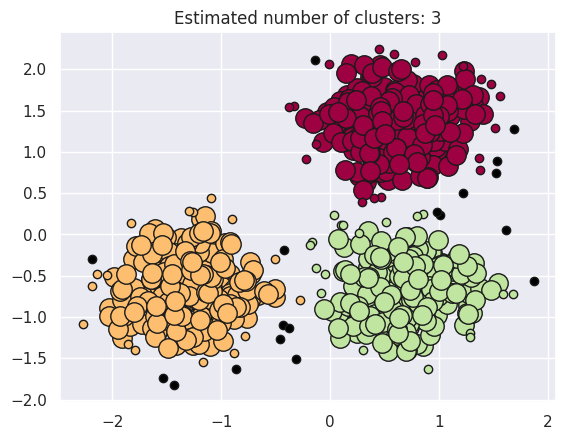

In [68]:
unique_labels = set(labels)

core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Warna hitam digunakan untuk merepresentasikan noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    # Memplot core samples dengan ukuran besar
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    # Memplot non-core samples dengan ukuran kecil
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()